# 02. 국내ETF(PREF01N001) EDA — 2026-08-24 배포본

스냅샷 파일 기준일: **2026-08-24** / 원본 1,780행 × 98컬럼

2026-07-11 배포본(1,734행 × 73컬럼) 대비 변경:
- **33컬럼 추가 / 8컬럼 삭제.** 추가분의 핵심은 세 블록이다.
  - `ref_*`(Refinitiv 참조): `ref_base_index`·`ref_ast_type`·`ref_geo_focus`·`ref_fund_mgmt_co`
  - 분배금: `pd_dvid_cycl`·`pd_dvid_yield`·`pd_divd_amt_ann`·`pd_dvid_pay_cnt` 등 9종
  - 변동성/펀더멘털: `du_vlty_*` 5종, `fn_*` 8종
  - 식별자: `pd_isin_cd`·`pd_ticker`·`pd_ric`
- 삭제분은 07-11 배포본에서 **전량 결측이던 컬럼들**이다(`nru_mkt_inav`·`pd_sect_nm` 등).
- `du_diff_rt`(괴리율)·`du_chas_errt`(추적오차율)에 **실제 값이 들어왔다**(§5).
- `ru_mkt_price`·`ru_mkt_volume`이 채워졌다 — 단 기준일 컬럼이 없다(§5 말미 경고).

핵심 쟁점:
1. 이 테이블은 여전히 **ETF와 ETN이 섞여 있다.** 분리하지 않으면 모든 통계가 오염된다.
2. 총보수(`cu_charge_rt`)는 여전히 82% 결측이지만, **기초지수는 `ref_base_index`로 해소되었다.**

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"

df = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260824.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PREF01N001_etf_kr_schema_20260824.csv", dtype=str, keep_default_na=False)
# axis_sample은 08-24 배포본에서 제공되지 않는다(schema.xlsx의 Sheet2_Sample 폐지).
# 08-24 데이터만 사용하는 방침이므로 파일이 없으면 해당 축 대조 셀은 건너뛴다.
_ax = CSV / "PREF01N001_etf_kr_axis_sample_20260711.csv"
axis = pd.read_csv(_ax, dtype=str, keep_default_na=False) if _ax.exists() else None
if axis is None:
    print("[skip] PREF01N001_etf_kr_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다")
ko = dict(zip(schema.column, schema.comment_ko))  # 컬럼 -> 한글 코멘트
print(df.shape, schema.shape, axis.shape if axis is not None else '(axis 없음)')

[skip] PREF01N001_etf_kr_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다
(1780, 98) (98, 5) (axis 없음)


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. ETF / ETN 분리 — 모든 통계의 전제

In [3]:
print(df.pd_grp_no.value_counts().to_string())
etf = df[df.pd_grp_no == "ETF"].copy()
etn = df[df.pd_grp_no == "ETN"].copy()
print("\nETF:", len(etf), "/ ETN:", len(etn))

pd_grp_no
ETF    1235
ETN     545

ETF: 1235 / ETN: 545


In [4]:
# 상품군별 결측률 차이 — ETN은 애초에 다른 필드 셋을 쓴다.
cmp_miss = pd.DataFrame(
    {
        "전체": (df == "").mean(),
        "ETF": (etf == "").mean(),
        "ETN": (etn == "").mean(),
    }
).round(4)
cmp_miss["한글명"] = [ko.get(c, "") for c in cmp_miss.index]
cmp_miss[(cmp_miss.ETF - cmp_miss.ETN).abs() > 0.1].sort_values("전체", ascending=False)

,전체,ETF,ETN,한글명
fn_average_coupon,0.8882,0.8389,1.0000,평균쿠폰이자율
fn_effective_maturity,0.8792,0.8259,1.0000,실질만기
fn_nominal_maturity,0.8792,0.8259,1.0000,명목만기
cu_charge_rt,0.8781,0.8243,1.0000,총보수요율
cu_charge_etc_rt,0.8781,0.8243,1.0000,기타비용요율
pd_divd_amt_ann,0.5343,0.3287,1.0000,연간 추정 분배금
fn_portfolio_dt,0.3719,0.0947,1.0000,포트폴리오 기준일
fn_base_dt,0.3511,0.0648,1.0000,펀더멘털 기준일
pd_dvid_prc_base_dt,0.3213,0.0219,1.0000,분배금 계산 NAV 기준일
pd_dvid_pay_months,0.3213,0.0219,1.0000,분배 지급월


> **시사점:** 1,780행 중 **ETN 545건(30.6%)** 이 섞여 있다(07-11: 532건/30.7% — 비율 그대로). ETN은 총보수(cu_charge_rt) 100% 결측, 운용전략은 전부 `C`로 채워지는 등 스키마 사용 방식이 다르다. "국내 ETF는 몇 개인가" 같은 기본 질의조차 `pd_grp_no=='ETF'` 필터 없이는 30% 과대 계상되므로, 온톨로지에서 **ETF와 ETN은 형제 클래스로 분리**해야 한다. 이하 통계는 별도 표기가 없으면 ETF 1,202건 기준.

## 2. 기준일 3종

In [5]:
pd.DataFrame(
    {
        "du_upt_dt(일간)": df.du_upt_dt.replace("", "(결측)").value_counts().head(5),
        "cu_upt_dt(변동)": df.cu_upt_dt.replace("", "(결측)").value_counts().head(5),
        "wu_upt_dt(주간)": df.wu_upt_dt.replace("", "(결측)").value_counts().head(5),
        "ref_base_dt(신설)": df.ref_base_dt.replace("", "(결측)").value_counts().head(5),
        "du_nav_base_dt(신설)": df.du_nav_base_dt.replace("", "(결측)").value_counts().head(5),
        "fn_base_dt(신설)": df.fn_base_dt.replace("", "(결측)").value_counts().head(5),
    }
)

,du_upt_dt(일간),cu_upt_dt(변동),wu_upt_dt(주간),ref_base_dt(신설),du_nav_base_dt(신설),fn_base_dt(신설)
(결측),182.0,182.0,4.0,572.0,182.0,625.0
20260520,NaN,8.0,NaN,NaN,NaN,NaN
20260521,8.0,NaN,NaN,NaN,8.0,NaN
20260601,NaN,5.0,NaN,NaN,NaN,NaN
20260602,5.0,NaN,NaN,NaN,5.0,NaN
20260722,NaN,10.0,NaN,NaN,NaN,NaN
20260723,10.0,NaN,NaN,NaN,10.0,NaN
20260821,1534.0,NaN,1776.0,NaN,1534.0,NaN
20260822,NaN,NaN,NaN,1208.0,NaN,1155.0
20260824,NaN,1534.0,NaN,NaN,NaN,NaN


> **시사점:** 갱신일이 **2026-08-21 ~ 08-24**로 모여 파일명 기준일과의 괴리가 사라졌다(07-11 배포본은 4주 시차). 국내채권도 08-21이므로 **채권↔ETF 교차 비교의 시점 정합이 처음으로 성립**한다(07-11 배포본은 2월 vs 6월로 4개월 벌어져 있었다). 다만 `du_upt_dt`(일간, 08-21)와 `cu_upt_dt`(변동정보, 08-24)는 여전히 3일 차이가 나므로 가격류와 상품속성류의 기준일은 따로 표기한다.

## 3. 결측의 벽 — "RDB 단독으로 답변 불가" 컬럼

In [6]:
wall = []
for c in df.columns:
    s = etf[c]
    nun = s[s != ""].nunique()
    wall.append(
        {
            "컬럼": c,
            "한글명": ko.get(c, ""),
            "ETF결측률": round((s == "").mean(), 4),
            "고유값수(결측제외)": nun,
            "판정": (
                "전량결측" if (s == "").all()
                else "상수(정보량0)" if nun <= 1
                else "고결측(>50%)" if (s == "").mean() > 0.5
                else "사용가능"
            ),
        }
    )
wall = pd.DataFrame(wall)
wall[wall.판정 != "사용가능"].sort_values(["판정", "ETF결측률"], ascending=[True, False]).reset_index(drop=True)

,컬럼,한글명,ETF결측률,고유값수(결측제외),판정
0,cu_base_index,기초지수,0.9547,19,고결측(>50%)
1,fn_average_quality,평균신용품질,0.9393,32,고결측(>50%)
2,fn_average_coupon,평균쿠폰이자율,0.8389,196,고결측(>50%)
3,fn_effective_maturity,실질만기,0.8259,212,고결측(>50%)
4,fn_nominal_maturity,명목만기,0.8259,212,고결측(>50%)
5,cu_charge_rt,총보수요율,0.8243,17,고결측(>50%)
6,cu_charge_etc_rt,기타비용요율,0.8243,1,상수(정보량0)
7,fn_base_dt,펀더멘털 기준일,0.0648,1,상수(정보량0)
8,pd_spac_yn,SPAC 여부,0.0478,1,상수(정보량0)
9,pd_dvid_base_dt,분배정보 기준일,0.0219,1,상수(정보량0)


In [7]:
# 대표 사례를 수치로 못박는다.
for c in ["cu_charge_rt", "cu_base_index", "ref_base_index", "du_chas_errt", "du_diff_rt",
          "pd_dvid_cycl", "pd_dvid_yield", "ru_mkt_price", "ru_mkt_volume"]:
    s = etf[c]
    print(f"{c:16s} ({ko.get(c,''):12s}) 결측 {(s=='').mean():6.1%}  값 {list(s[s!=''].unique()[:3])}")

cu_charge_rt     (총보수요율       ) 결측  82.4%  값 ['0', '0.49', '0.52']
cu_base_index    (기초지수        ) 결측  95.5%  값 ['Rogers International Commodity TR', 'KRX 미디어통신', 'MSCI ACWI']
ref_base_index   (refinitiv 벤치마크) 결측   2.2%  값 ['KRX Bio TOP 10 KRW', 'S&P 500 Daily JPY Hedged CR', 'KAP 27-12 Corporate Bond TR (AA- or higher)']
du_chas_errt     (추적오차율       ) 결측   4.8%  값 ['35.14', '0.34', '0.25']
du_diff_rt       (괴리율         ) 결측   4.8%  값 ['-0.11', '0.28', '0.06']
pd_dvid_cycl     (분배주기(A/Q/M/S)) 결측   2.2%  값 ['Q', 'A', 'M']
pd_dvid_yield    (연환산 분배수익률   ) 결측   2.2%  값 ['0.040816', '1.717791', '1.542998']
ru_mkt_price     (현재가         ) 결측   0.2%  값 ['9050', '11250', '10185']
ru_mkt_volume    (거래량         ) 결측   0.2%  값 ['346324', '909', '54905']


In [8]:
# ★ 07-11 배포본에서 "답변 불가"로 판정했던 필드가 신설 컬럼으로 해소되었는지 대조한다.
prev = {
    "기초지수":     ("cu_base_index", "ref_base_index"),
    "분배금 주기":  ("pd_dvid_cycl", "pd_dvid_cycl"),
    "괴리율":       ("du_diff_rt", "du_diff_rt"),
    "추적오차율":   ("du_chas_errt", "du_chas_errt"),
    "실시간 시세":  ("ru_mkt_price", "ru_mkt_price"),
}
pd.DataFrame(
    [
        {"질의 대상": k, "구 컬럼": old, "신 컬럼": new,
         "신 컬럼 결측률": round((etf[new] == "").mean(), 4),
         "신 컬럼 고유값": int(etf[new][etf[new] != ""].nunique())}
        for k, (old, new) in prev.items()
    ]
)

,질의 대상,구 컬럼,신 컬럼,신 컬럼 결측률,신 컬럼 고유값
0,기초지수,cu_base_index,ref_base_index,0.0219,905
1,분배금 주기,pd_dvid_cycl,pd_dvid_cycl,0.0219,4
2,괴리율,du_diff_rt,du_diff_rt,0.0478,232
3,추적오차율,du_chas_errt,du_chas_errt,0.0478,497
4,실시간 시세,ru_mkt_price,ru_mkt_price,0.0024,1089


> **시사점:** **"결측의 벽"이 대부분 무너졌다.** `ref_base_index`(결측 2.2%, 905종)가 `cu_base_index`(95.5%)를 대체하고, 분배금 주기·괴리율·추적오차율·실시간 시세가 모두 채워졌다. 07-11 배포본에서 "답변 불가"로 분류했던 **"이 ETF가 추종하는 지수는?", "분배금은 언제 나오나?", "괴리율이 큰 ETF는?"이 전부 답변 가능으로 전환**된다.
> 남은 벽은 **총보수(`cu_charge_rt`) 82.4% 결측** 하나뿐이며 이는 여전히 LSEG `ter` 보완이 필요하다(§05 노트북). 또한 `cu_charge_etc_rt`(기타비용요율)는 유효값이 전부 `0`인 더미이므로 "총비용"을 이 컬럼으로 만들면 안 된다.

## 4. 순자산 3종 — 표준 1개 확정

In [9]:
aum = pd.DataFrame(
    {
        "pd_net_tamt(순자산총액)": num(etf.pd_net_tamt),
        "du_last_aum(최종AUM)": num(etf.du_last_aum),
        "pd_circ_net_tamt(유통순자산)": num(etf.pd_circ_net_tamt),
    }
)
pd.concat([aum.notna().sum().rename("유효건수"), aum.describe().T], axis=1).round(0)

,유효건수,count,mean,std,min,25%,50%,75%,max
pd_net_tamt(순자산총액),1176,1176.0,3.846128e+11,1.380378e+12,89477660.0,1.640428e+10,5.110229e+10,2.278709e+11,2.547481e+13
du_last_aum(최종AUM),1176,1176.0,3.831157e+11,1.381647e+12,0.0,1.626193e+10,5.119912e+10,2.276751e+11,2.583424e+13
pd_circ_net_tamt(유통순자산),1176,1176.0,1.922808e+11,9.304333e+11,0.0,0.000000e+00,8.279125e+09,6.255750e+10,2.047056e+13


In [10]:
print("상관계수:")
print(aum.corr().round(4).to_string())
both = aum.dropna(subset=["pd_net_tamt(순자산총액)", "du_last_aum(최종AUM)"])
rel = (both["du_last_aum(최종AUM)"] - both["pd_net_tamt(순자산총액)"]).abs() / both["pd_net_tamt(순자산총액)"].replace(0, np.nan)
print("\n두 값의 상대 차이:")
print(rel.describe().round(4).to_string())
print("\n1% 이상 차이나는 종목:", int((rel > 0.01).sum()))

상관계수:
                         pd_net_tamt(순자산총액)  du_last_aum(최종AUM)  pd_circ_net_tamt(유통순자산)
pd_net_tamt(순자산총액)                   1.0000              0.9998                   0.6445
du_last_aum(최종AUM)                   0.9998              1.0000                   0.6410
pd_circ_net_tamt(유통순자산)              0.6445              0.6410                   1.0000

두 값의 상대 차이:
count    1176.0000
mean        0.0235
std         0.0751
min         0.0000
25%         0.0042
50%         0.0107
75%         0.0233
max         1.0000

1% 이상 차이나는 종목: 608


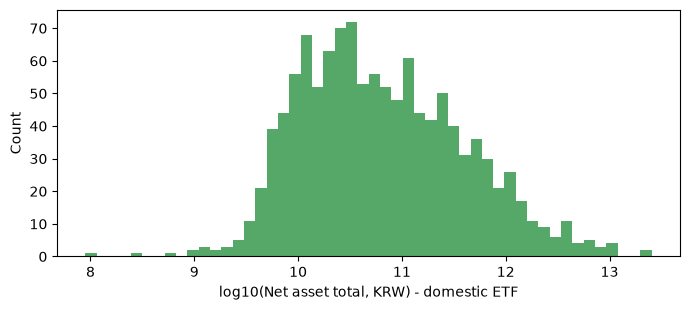

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
np.log10(aum["pd_net_tamt(순자산총액)"].dropna().clip(lower=1)).plot.hist(bins=50, ax=ax, color="#55A868")
ax.set_xlabel("log10(Net asset total, KRW) - domestic ETF")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

> **시사점:** `pd_net_tamt`와 `du_last_aum`은 상관 0.9998로 동일 지표지만 유효건수가 다르고(1,142 vs 1,044) **139종목은 1% 이상 값이 어긋난다**. 반면 `pd_circ_net_tamt`(유통순자산)은 상관 0.62에 25%분위가 0으로, 전혀 다른 개념(유통주식 기준)이다. **`pd_net_tamt`을 표준 AUM으로 단일 채택**한다 — 세 개를 모두 노출하면 "이 ETF 순자산은?"에 서로 다른 숫자가 나가는 사고가 난다. 규모는 로그정규 분포로 최소 0.9억 ~ 최대 28.4조까지 6자리 스케일 차이가 나므로 "대형 ETF"는 분위수로 정의해야 한다.

## 5. 괴리율(du_diff_rt)·추적오차율(du_chas_errt) — ★ 07-11의 '껍데기'가 실측값으로 바뀌었다

In [12]:
dr, ce = num(etf.du_diff_rt), num(etf.du_chas_errt)
pd.DataFrame({"du_diff_rt(괴리율)": dr.describe(), "du_chas_errt(추적오차율)": ce.describe()}).round(4)

,du_diff_rt(괴리율),du_chas_errt(추적오차율)
count,1176.0000,1176.0000
mean,14.9377,3.5880
std,511.6290,6.6476
min,-1.9000,0.0000
25%,-0.2200,0.4175
50%,0.0100,0.9600
75%,0.2300,2.6025
max,17545.2300,51.9700


In [13]:
print("du_diff_rt  고유값 수:", etf.du_diff_rt[etf.du_diff_rt != ""].nunique(),
      "예시:", sorted(etf.du_diff_rt[etf.du_diff_rt != ""].unique())[:5])
print("du_chas_errt 고유값 수:", etf.du_chas_errt[etf.du_chas_errt != ""].nunique(),
      "예시:", sorted(etf.du_chas_errt[etf.du_chas_errt != ""].unique())[:5])
print("→ 07-11 배포본에서는 두 컬럼 모두 유효값 종류가 '0.00' 하나뿐이었다.")
print()
# ★ 적재값이 신뢰 가능한지 검증: 같은 행의 종가/NAV로 재계산해 대조한다.
chk = etf[(etf.du_clpr != "") & (etf.du_last_nav != "")].copy()
chk["재계산_괴리율"] = (num(chk.du_clpr) / num(chk.du_last_nav) - 1) * 100
chk["적재_괴리율"] = num(chk.du_diff_rt)
chk["절대차"] = (chk.재계산_괴리율 - chk.적재_괴리율).abs()
print("적재값 vs 재계산 절대차:")
print(chk.절대차.describe().round(4).to_string())
print("\n절대차 > 0.1%p 종목:", int((chk.절대차 > 0.1).sum()), "/", len(chk))
print("|괴리율| > 1% 종목(적재값 기준):", int((chk.적재_괴리율.abs() > 1).sum()))

du_diff_rt  고유값 수: 232 예시: ['-0.01', '-0.02', '-0.03', '-0.04', '-0.05']
du_chas_errt 고유값 수: 497 예시: ['0', '0.01', '0.02', '0.03', '0.04']
→ 07-11 배포본에서는 두 컬럼 모두 유효값 종류가 '0.00' 하나뿐이었다.

적재값 vs 재계산 절대차:


count    1176.0000
mean        0.9402
std         9.6299
min         0.0000
25%         0.0012
50%         0.0025
75%         0.0038
max       100.0000

절대차 > 0.1%p 종목: 16 / 1176
|괴리율| > 1% 종목(적재값 기준): 66


In [14]:
chk.loc[chk.적재_괴리율.abs().sort_values(ascending=False).head(6).index,
        ["pd_abrv_nm", "du_clpr", "du_last_nav", "du_diff_rt", "재계산_괴리율", "절대차"]]

,pd_abrv_nm,du_clpr,du_last_nav,du_diff_rt,재계산_괴리율,절대차
538,ACE 러시아MSCI(합성),8535,48.37,17545.23,17545.234650,0.004650
292,ACE BYD밸류체인액티브,10355,10129.03,2.23,2.230915,0.000915
160,TIGER 차이나글로벌리더스TOP3+,10510,10300.12,2.04,2.037646,0.002354
1375,TIGER 이머징마켓MSCI레버리지(합성 H),16620,16297.68,1.98,1.977705,0.002295
380,KODEX 차이나AI반도체TOP10,13555,13292.39,1.98,1.975642,0.004358
781,PLUS TDF2060액티브 적격,18900,18536.93,1.96,1.958631,0.001369


In [15]:
# 기준일 컬럼이 함께 신설되었다 — 괴리율/추적오차율은 이제 as_of를 붙여 인용할 수 있다.
for c in ["du_diff_rt_base_dt", "du_chas_errt_base_dt", "du_vlty_base_dt"]:
    print(f"{c:22s}", df[c].replace("", "(결측)").value_counts().head(3).to_dict())

du_diff_rt_base_dt     {'20260821': 1534, '(결측)': 182, '20260723': 10}
du_chas_errt_base_dt   {'20260821': 1534, '(결측)': 182, '20260723': 10}
du_vlty_base_dt        {'20260821': 1584, '(결측)': 86, '20260723': 10}


In [16]:
# ⚠️ 반대로 ru_mkt_price / ru_mkt_volume 은 값이 채워졌으나 기준일 컬럼이 없다.
print("ru_* 계열 컬럼:", [c for c in df.columns if c.startswith("ru_")])
print("ru_mkt_price 결측률:", round((etf.ru_mkt_price == "").mean(), 4))
print("기준일 컬럼 존재 여부:", [c for c in df.columns if c.startswith("ru_") and c.endswith("dt")] or "없음")

ru_* 계열 컬럼: ['ru_mkt_price', 'ru_mkt_volume']
ru_mkt_price 결측률: 0.0024
기준일 컬럼 존재 여부: 없음


> **시사점:** 07-11 배포본 3대 함정 중 하나였던 **"괴리율 더미"가 해소되었다.** 적재값과 종가/NAV 재계산이 중앙값 0.0025%p 수준으로 일치하므로 `du_diff_rt`·`du_chas_errt`를 **그대로 온톨로지에 실어도 된다**. 전용 기준일 컬럼(`du_diff_rt_base_dt` 등)까지 신설되어 as_of 표기도 가능하다.
>
> ⚠️ 대신 새 위험이 생겼다. `ru_mkt_price`·`ru_mkt_volume`(실시간 시세)은 07-11 배포본에서 전량 결측이라 무해했으나 **이번엔 값이 채워졌는데 기준일 컬럼이 없다.** 어느 시점 값인지 증명할 수 없으므로 **관계 테이블·온톨로지에 적재 금지**이며, 답변에 쓰면 룩어헤드(look-ahead) 위험이 그대로 남는다. 가격은 기준일이 명시된 `du_clpr`(+`du_nav_base_dt`)만 사용한다.

## 6. 분류 축 실측 · 주최측 7축 대조

In [17]:
for c in ["wu_inv_ast_type", "wu_inv_rgn", "cu_lev_fector", "cu_strtegy", "pd_sect_cd", "pd_risk_nm", "pd_pen_tr_yn", "pd_pen_risk_nm"]:
    print(f"=== {c} ({ko.get(c,'')})")
    print(etf[c].replace("", "(결측)").value_counts().head(12).to_string(), "\n")

=== wu_inv_ast_type (투자자산군)
wu_inv_ast_type
주식      804
채권      142
대체투자    132
혼합자산     85
단기자금     31
원자재      20
기타       19
부동산       2 

=== wu_inv_rgn (투자지역)
wu_inv_rgn
국내         715
미국         332
글로벌         72
중국          42
아시아         33
인도          12
남미/북미       12
유럽           6
이머징/브릭스      5
일본           5
베트남          1 

=== cu_lev_fector (배수)
cu_lev_fector
1       1103
2         72
(결측)      59
-1         1 

=== cu_strtegy (운용전략)
cu_strtegy
실물복제    763
액티브     358
합성복제     82
(결측)     32 

=== pd_sect_cd (ETF 섹터코드)
pd_sect_cd
2       1160
(결측)      59
8         16 

=== pd_risk_nm (상품등급명)
pd_risk_nm
높은위험(2등급)      690
매우높은위험(1등급)    232
낮은위험(5등급)      117
보통위험(4등급)       90
다소높은위험(3등급)     85
매우낮은위험(6등급)     21 

=== pd_pen_tr_yn (연금거래가능여부)
pd_pen_tr_yn
Y    1022
N     213 

=== pd_pen_risk_nm (연금거래위험구분)
pd_pen_risk_nm
위험자산    804
안전자산    218
N       213 



In [18]:
# 정체불명 cu_strtegy='C' 409건의 정체 규명
print(pd.crosstab(df.cu_strtegy.replace("", "(결측)"), df.pd_grp_no).to_string())
print("\ncu_strtegy=='C' 인 상품 예시:")
print(df.loc[df.cu_strtegy == "C", "pd_abrv_nm"].head(8).to_string())

pd_grp_no   ETF  ETN
cu_strtegy          
(결측)         32  123
C             0  422
실물복제        763    0
액티브         358    0
합성복제         82    0

cu_strtegy=='C' 인 상품 예시:
38     미래에셋 1.5X S&P500 VIX S/T선물 ETN
102           신한 인버스 2X S&P500 선물 ETN
189                    키움 전력 TOP5 ETN
238            KB 차이나 중형주 CSI 500 ETN
277               신한 레버리지 은 선물 ETN(H)
293             신한 인버스 2X 은 선물 ETN(H)
317                  신한 레버리지 금 선물 ETN
333               신한 인버스 2X 구리 선물 ETN


In [19]:
# pd_sect_cd는 코드만 있고 명칭(pd_sect_nm)이 전량 결측 → 다른 컬럼으로 의미 역추정
pd.crosstab(etf.pd_sect_cd.replace("", "(결측)"), etf.wu_inv_ast_type)

wu_inv_ast_type,기타,단기자금,대체투자,부동산,원자재,주식,채권,혼합자산
pd_sect_cd,,,,,,,,
(결측),0,1,5,2,1,26,20,4
2,19,30,111,0,19,778,122,81
8,0,0,16,0,0,0,0,0


In [20]:
# 연금 관련: pd_pen_tr_yn == 'N' 이면 pd_pen_risk_nm 도 'N' 으로 채워진다(값이 아니라 플래그 재사용)
pd.crosstab(df.pd_pen_tr_yn, df.pd_pen_risk_nm)

pd_pen_risk_nm,N,안전자산,위험자산
pd_pen_tr_yn,,,
N,757,0,0
Y,0,218,805


In [21]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")] if axis is not None else []
pd.DataFrame([{"축": c, "값 분포": dict(axis[c].value_counts())} for c in axis_cols]) if axis_cols else "axis_sample 미제공 — 대조 생략"

'axis_sample 미제공 — 대조 생략'

In [22]:
pd.DataFrame(
    [
        ("axis_assetType", "wu_inv_ast_type", "가능", "주식/채권/원자재/혼합/단기자금/통화/부동산 8종, 결측 0%"),
        ("axis_region", "wu_inv_rgn", "가능", "국내/해외 이분은 wu_inv_rgn=='국내' 여부로 직접 산출"),
        ("axis_strategy", "cu_strtegy", "부분", "액티브 358 / 실물복제 763 / 합성복제 82 — 여전히 두 축이 한 컬럼(ETN은 'C')"),
        ("axis_replicationMethod", "cu_strtegy", "부분", "실물/합성 대응하나 ETN·결측 32건은 판정 불가"),
        ("axis_leverageType", "cu_lev_fector", "가능", "ETF는 1/2/-1 3종, 결측 59건"),
        ("axis_underlyingScope", "ref_base_index", "부분(개선)", "★ 기초지수명 905종이 채워져 지수 성격으로 근사 가능. 직접 코드는 여전히 없음"),
        ("axis_distributionType", "pd_dvid_cycl", "가능(신규)", "★ 08-24 신설. M/Q/A/S 등 결측 2.2%"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_assetType,wu_inv_ast_type,가능,"주식/채권/원자재/혼합/단기자금/통화/부동산 8종, 결측 0%"
1,axis_region,wu_inv_rgn,가능,국내/해외 이분은 wu_inv_rgn=='국내' 여부로 직접 산출
2,axis_strategy,cu_strtegy,부분,액티브 358 / 실물복제 763 / 합성복제 82 — 여전히 두 축이 한 컬럼(ETN은 'C')
3,axis_replicationMethod,cu_strtegy,부분,실물/합성 대응하나 ETN·결측 32건은 판정 불가
4,axis_leverageType,cu_lev_fector,가능,"ETF는 1/2/-1 3종, 결측 59건"
5,axis_underlyingScope,ref_base_index,부분(개선),★ 기초지수명 905종이 채워져 지수 성격으로 근사 가능. 직접 코드는 여전히 없음
6,axis_distributionType,pd_dvid_cycl,가능(신규),★ 08-24 신설. M/Q/A/S 등 결측 2.2%


In [23]:
# underlyingScope / distributionType 을 상품명 토큰으로 근사할 수 있는지 실측
print("pd_dvid_cycl(분배주기):", etf.pd_dvid_cycl.replace("", "(결측)").value_counts().to_dict())
print("pd_dvid_pay_cnt(연 지급횟수):", etf.pd_dvid_pay_cnt.replace("", "(결측)").value_counts().head(6).to_dict())
print()
print("상품명에 'TR' 포함:", int(etf.pd_abrv_nm.str.contains(r"TR\b|TR$", regex=True).sum()), "건")
print("상품명에 '(H)'(환헤지) 포함:", int(etf.pd_abrv_nm.str.contains(r"\(H\)").sum()), "건")
print("상품명에 '레버리지|인버스' 포함:", int(etf.pd_abrv_nm.str.contains("레버리지|인버스").sum()), "건")
print("상품명에 '커버드콜' 포함:", int(etf.pd_abrv_nm.str.contains("커버드콜").sum()), "건")

pd_dvid_cycl(분배주기): {'Q': 698, 'A': 306, 'M': 196, '(결측)': 27, 'S': 8}
pd_dvid_pay_cnt(연 지급횟수): {'4': 698, '1': 306, '12': 196, '(결측)': 27, '2': 8}

상품명에 'TR' 포함: 18 건
상품명에 '(H)'(환헤지) 포함: 66 건
상품명에 '레버리지|인버스' 포함: 110 건
상품명에 '커버드콜' 포함: 62 건


> **시사점(08-24):** 재현 가능 축이 3축 → **5축**으로 늘었다(assetType/region/leverageType + distributionType 신설 + underlyingScope 부분). 07-11 배포본 판정은 아래와 같이 유지된다:
>
> 7축 중 3축(assetType/region/leverageType)만 컬럼으로 깨끗이 재현되고, `cu_strtegy` 하나가 **운용전략(액티브/패시브)과 복제방식(실물/합성)이라는 서로 다른 두 축을 한 컬럼에 우겨 넣은 상태**다. 온톨로지에서는 이를 `strategy`와 `replicationMethod` 두 속성으로 분리해야 한다. 결정적으로 `cu_strtegy=='C'` 409건은 **전부 ETN**이며(ETF에는 0건) 운용전략 값이 아니라 상품군 플래그의 잔재다 — 이 값을 전략으로 해석하면 안 된다. `underlyingScope`·`distributionType`은 대응 컬럼이 아예 없어 상품명 파싱이 유일한 경로다.

## 7. 브랜드 파싱 — 존재하지 않는 상품 판정

In [24]:
df["brand"] = df.pd_abrv_nm.str.split().str[0]
etf["brand"] = etf.pd_abrv_nm.str.split().str[0]
brand_tbl = pd.crosstab(df.brand, df.pd_grp_no)
brand_tbl["합계"] = brand_tbl.sum(axis=1)
brand_tbl.sort_values("합계", ascending=False).head(25)

pd_grp_no,ETF,ETN,합계
brand,,,
KODEX,243,0,243
TIGER,237,0,237
RISE,150,0,150
ACE,120,0,120
메리츠,0,97,97
PLUS,92,0,92
KIWOOM,81,0,81
SOL,81,0,81
한투,0,73,73


In [25]:
# 브랜드 ↔ 운용사 표기 매핑 (cu_fund_mgmt_co 는 97종으로 표기가 혼재)
print("cu_fund_mgmt_co 고유:", df.cu_fund_mgmt_co.nunique())
print("ref_fund_mgmt_co 고유(신설):", etf.ref_fund_mgmt_co[etf.ref_fund_mgmt_co != ""].nunique(),
      "| 결측", round((etf.ref_fund_mgmt_co == "").mean(), 4))
print(etf.ref_fund_mgmt_co.replace("", "(결측)").value_counts().head(8).to_string())
bm = (
    df.groupby("brand")
    .agg(상품수=("pd_itm_no", "size"), 운용사표기=("cu_fund_mgmt_co", lambda s: sorted(set(s))), 상품군=("pd_grp_no", lambda s: sorted(set(s))))
    .sort_values("상품수", ascending=False)
)
bm.head(20)

cu_fund_mgmt_co 고유: 100
ref_fund_mgmt_co 고유(신설): 29 | 결측 0.0219
ref_fund_mgmt_co
Samsung Asset Management Co Ltd          243
Mirae Asset Global Investments Co Ltd    235
KB Asset Ltd                             144
Korea Investment Management Co Ltd       118
Hanwha Asset Management                   89
Shinhan Asset Management Co Ltd           80
Kiwoom Asset Management Co.,Ltd           76
NH-Amundi Asset Management Co Ltd         57


,상품수,운용사표기,상품군
brand,,,
KODEX,243,"[삼성, 삼성KODEX, 삼성KODEX10년국채선물인버스증권상장지수투자신탁[채권-파생형], 삼성KOD...",[ETF]
TIGER,237,"[TIGER, 미래에셋, 미래에셋TIGER, 미래에셋TIGER200IT증권상장지수투자신탁(주식), 미...",[ETF]
RISE,150,[KB],[ETF]
ACE,120,"[ACE, 한국투자]",[ETF]
메리츠,97,[메리츠증권 주식회사],[ETN]
PLUS,92,"[한화, 한화PLUS]",[ETF]
KIWOOM,81,[키움],[ETF]
SOL,81,"[신한, 신한SOL유럽탄소배출권선물인버스ICE특별자산상장지수투자신탁[탄소배출권-파생형](H)]",[ETF]
한투,73,[한국투자증권(주)],[ETN]


In [26]:
# 운용사 표기 혼재 실태: 같은 운용사가 법인격 유무로 여러 표기를 가진다
mg = df.cu_fund_mgmt_co.value_counts()
print(mg.head(20).to_string())
print("\n표기 정규화(법인격·공백 제거) 후 고유수:",
      df.cu_fund_mgmt_co.str.replace(r"\s+|주식회사|\(주\)|㈜|증권", "", regex=True).nunique(),
      "← 원본", df.cu_fund_mgmt_co.nunique())

cu_fund_mgmt_co
삼성             227
미래에셋           194
KB             150
한국투자           119
메리츠증권 주식회사      97
한화              88
키움              81
신한              80
한국투자증권(주)       73
신한투자증권 주식회사     71
삼성증권(주)         70
KB증권(주)         68
NH-Amundi       64
미래에셋증권 주식회사     60
엔에이치투자증권(주)     41
하나              29
키움증권(주)         27
삼성액티브           25
하나증권주식회사        24
타임폴리오           19

표기 정규화(법인격·공백 제거) 후 고유수: 93 ← 원본 100


In [27]:
# "존재하지 않는 상품" 판정 로직 시연
KNOWN_BRANDS = set(df.brand.unique())


def lookup(q):
    """자연어 상품명 질의 → (브랜드 유효성, 정확일치, 브랜드내 유사후보)"""
    tok = q.split()[0]
    if tok not in KNOWN_BRANDS:
        return f'"{q}" → 브랜드 "{tok}" 자체가 존재하지 않음 (환각 방지: 즉시 부정 응답)'
    exact = df[df.pd_abrv_nm.str.replace(" ", "") == q.replace(" ", "")]
    if len(exact):
        return f'"{q}" → 정확 일치 {len(exact)}건: {exact.pd_itm_no.iloc[0]}'
    key = q.replace(tok, "").replace(" ", "")
    cand = df[(df.brand == tok) & df.pd_abrv_nm.str.replace(" ", "").str.contains(re.escape(key[:3]), regex=True)]
    return f'"{q}" → 브랜드는 존재하나 해당 상품 없음. 같은 브랜드 유사 후보 {len(cand)}건: {cand.pd_abrv_nm.head(3).tolist()}'


for q in ["KODEX AI로봇", "KODEX 반도체", "TIGER 미국S&P500", "NOSUCH 성장주"]:
    print(lookup(q))

"KODEX AI로봇" → 브랜드는 존재하나 해당 상품 없음. 같은 브랜드 유사 후보 0건: []
"KODEX 반도체" → 정확 일치 1건: KR7091160002
"TIGER 미국S&P500" → 정확 일치 1건: KR7360750004
"NOSUCH 성장주" → 브랜드 "NOSUCH" 자체가 존재하지 않음 (환각 방지: 즉시 부정 응답)


> **시사점(08-24):** 브랜드 순위는 KODEX 243 / TIGER 237 / RISE 150 / ACE 120으로 07-11과 동일한 구조다. **결정적 개선은 `ref_fund_mgmt_co` 신설** — 운용사가 영문 정식명 29종으로 정규화되어 들어온다(`Samsung Asset Management Co Ltd` 등). 07-11 배포본에서 "운용사 100종, 일부 행에 상품 정식명칭 오염 → 필터로 사용 불가"였던 문제가 **커버 구간(결측 2.2%)에서 해소**된다. 07-11 판정은 아래와 같다:
>
> 상품약어명 선두 토큰이 곧 브랜드이며 KODEX 240 / TIGER 235 / RISE 147 / ACE 114 순이다. 브랜드는 **ETF와 ETN이 완전히 배타적**이다 — ETF는 영문 브랜드(KODEX·TIGER·RISE…), ETN은 증권사 한글명(메리츠·신한·한투·삼성·KB…)을 쓴다. 즉 브랜드 토큰만으로 상품군을 판정할 수 있다. 반면 `cu_fund_mgmt_co`는 "삼성"/"삼성증권(주)"/"삼성액티브"로 표기가 갈리는 데다 **일부 행에는 운용사 대신 상품 정식명칭이 통째로 들어가 있어**("삼성KODEX10년국채선물인버스증권상장지수투자신탁[채권-파생형]") 운용사 필터로 쓸 수 없다. 온톨로지에는 브랜드를 `ProductBrand` 노드로 세우고 운용사는 정규화 사전을 따로 만들어 연결해야 한다. `lookup()`이 보여주듯 **브랜드는 실재하지만 상품이 없는 경우("KODEX AI로봇")를 "브랜드 유효 + 상품 부재"로 분해 판정**하면, 그럴듯한 이름의 존재하지 않는 상품에 대한 환각을 구조적으로 차단할 수 있다.

## 8. 유효 상품 판정 (상장/판매/거래정지)

**주최측 안내(2026-08-24): 상장폐지·리스팅 종료 종목을 제외한 나머지는 모두 "구매 가능"으로 간주한다.**
따라서 아래 3조건 중 **상장 존속(`pd_lste_dt=='99991231'`)이 1차 기준**이고,
판매/거래정지 플래그는 보조 표기로 남긴다.

In [28]:
print("pd_lste_dt(거래종료일) 99991231 = 존속:", int((df.pd_lste_dt == "99991231").sum()))
print(pd.crosstab([df.pd_lste_dt == "99991231", df.pd_sale_yn], df.pd_tr_yn.replace("", "(결측)")).to_string())

pd_lste_dt(거래종료일) 99991231 = 존속: 1535


pd_tr_yn               (결측)     0   1
pd_lste_dt pd_sale_yn                
False      0              3   161  81
True       0              0     0   1
           1              0  1534   0


In [29]:
listed = etf.pd_lste_dt == "99991231"
alive = listed & (etf.pd_sale_yn == "1") & (etf.pd_tr_yn == "0")
print("[주최측 기준] 상장 존속 = 구매 가능 :", int(listed.sum()), "/ 전체 ETF", len(etf))
print("[구 기준] 상장+판매+거래 3조건 동시  :", int(alive.sum()))
print("\n제외 사유별:")
print("  상장폐지 예정/완료 :", int((etf.pd_lste_dt != "99991231").sum()))
print("  판매중지(sale_yn=0):", int((etf.pd_sale_yn != "1").sum()))
print("  거래정지(tr_yn=1)  :", int((etf.pd_tr_yn == "1").sum()))
print("\npd_lste_dt 상장폐지일 분포(99991231 제외):")
print(etf.loc[~listed, "pd_lste_dt"].value_counts().head(8).to_string())

[주최측 기준] 상장 존속 = 구매 가능 : 1161 / 전체 ETF 1235
[구 기준] 상장+판매+거래 3조건 동시  : 1160

제외 사유별:
  상장폐지 예정/완료 : 74
  판매중지(sale_yn=0): 75
  거래정지(tr_yn=1)  : 72

pd_lste_dt 상장폐지일 분포(99991231 제외):
pd_lste_dt
20250604    5
20260326    4
20250624    4
            3
20260625    3
20250926    3
20260709    3
20250918    3


> **시사점:** `pd_lste_dt='99991231'`이 "종료일 미정=존속" sentinel이다. **주최측 지침에 따라 구매가능 모집단은 상장 존속 ETF 1,161건**이며, 판매·거래정지까지 겹쳐 거는 구 정의(1,160건)와 실질 차이는 1건뿐이다. 세 조건은 거의 같은 종목을 가리켜 사실상 하나의 상태 플래그다. `pd_tr_yn`이 "거래정지여부"인데 값이 `0`=정상인 역방향 플래그라 부호를 뒤집어 읽으면 결과가 정반대가 된다(스키마 한글명 오타 '상품거래정지혀부'도 그대로 존재).

## 9. 수익률 6종 — 결측 계단과 극단값

In [30]:
ers = ["du_er_1d", "du_er_1m", "du_er_3m", "du_er_6m", "du_er_ytd", "du_er_1y"]
pd.DataFrame(
    {
        "한글명": [ko.get(c, "") for c in ers],
        "ETF결측률": [round((etf[c] == "").mean(), 4) for c in ers],
        "min": [num(etf[c]).min() for c in ers],
        "median": [round(num(etf[c]).median(), 2) for c in ers],
        "max": [num(etf[c]).max() for c in ers],
    },
    index=ers,
)

,한글명,ETF결측률,min,median,max
du_er_1d,수익률_1D,0.0486,-100.0,-0.64,9.14
du_er_1m,수익률_1M,0.0583,-100.0,0.01,30.78
du_er_3m,수익률_3M,0.0883,-100.0,-8.06,26.25
du_er_6m,수익률_6M,0.1271,-100.0,0.62,83.84
du_er_ytd,수익률_YTD,0.1368,-100.0,4.08,247.00
du_er_1y,수익률_1Y,0.1798,-100.0,13.29,926.89


In [31]:
# 장기 수익률 결측 = 신규 상장 종목인지 확인
etf["lstg"] = pd.to_datetime(etf.pd_lstg_dt.where(etf.pd_lstg_dt.str.fullmatch(r"\d{8}")), format="%Y%m%d", errors="coerce")
print("du_er_1y 결측 종목의 상장일 분포:")
print(etf.loc[etf.du_er_1y == "", "lstg"].dt.year.value_counts().sort_index().to_string())
print("\ndu_er_1y 유효 종목의 상장일 중앙값:", etf.loc[etf.du_er_1y != "", "lstg"].median())

du_er_1y 결측 종목의 상장일 분포:
lstg
2021.0      4
2022.0     11
2023.0      8
2024.0      1
2025.0     71
2026.0    124

du_er_1y 유효 종목의 상장일 중앙값: 2022-05-17 00:00:00


> **시사점:** 1D→1Y로 갈수록 결측이 계단식으로 늘어난다(4.5%→18.0%). 1Y 결측 종목의 199/215가 2025~2026년 상장으로, **결측 = 데이터 누락이 아니라 "이력이 아직 없음"** 이다. RAG는 이 둘을 구분해 "1년 수익률 없음"이 아니라 "상장 1년 미만이라 산출 불가"로 답해야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| ETN 혼입 | 545건(30.6%) | ETF/ETN 형제 클래스 분리 필수 (변화 없음) |
| 총보수 결측(ETF) | 82.4% | ★ 유일하게 남은 결측의 벽 — LSEG `ter` 보완 필요 |
| 기초지수 | `ref_base_index` 결측 2.2% / 905종 | ★ 95.2% 결측 → 해소. 지수 엔티티 연결 가능 |
| 분배금 주기 | `pd_dvid_cycl` 결측 2.2% | ★ 전량결측 → 해소. distributionType 축 성립 |
| 괴리율·추적오차율 | 실측값, 재계산과 일치(중앙 0.0025%p) | ★ 더미 → 실값. 온톨로지 탑재 가능 |
| 실시간 시세 `ru_*` | 값은 채워졌으나 **기준일 컬럼 없음** | ⚠️ 신규 룩어헤드 위험 — 적재 금지 |
| 전량결측·상수 컬럼 | 4 + 14 | 온톨로지 미탑재 |
| cu_strtegy='C' | 422건 전부 ETN | 전략값 아님, 오독 위험 (변화 없음) |
| 구매가능 ETF | 상장 존속 1,161 / 1,235 | 주최측 지침 = 상장폐지만 제외 |
| 운용사 | `ref_fund_mgmt_co` 영문 정식명 29종 | ★ ER 난제 대부분 해소 |
| 브랜드 | KODEX 243 / TIGER 237 … | ETF=영문·ETN=한글로 배타적 |